In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({"font.size": 11})

RESULTS_DIR = Path("../data/results")

In [28]:
csv_path = list(RESULTS_DIR.glob("routing_results_*.csv"))[0]
df = pd.read_csv(csv_path)
model_name = csv_path.stem.replace("routing_results_", "")
routers = [c for c in df.columns if c.endswith("_tool") and c != "ground_truth"]

labels = ["local", "web", "uncertain"]

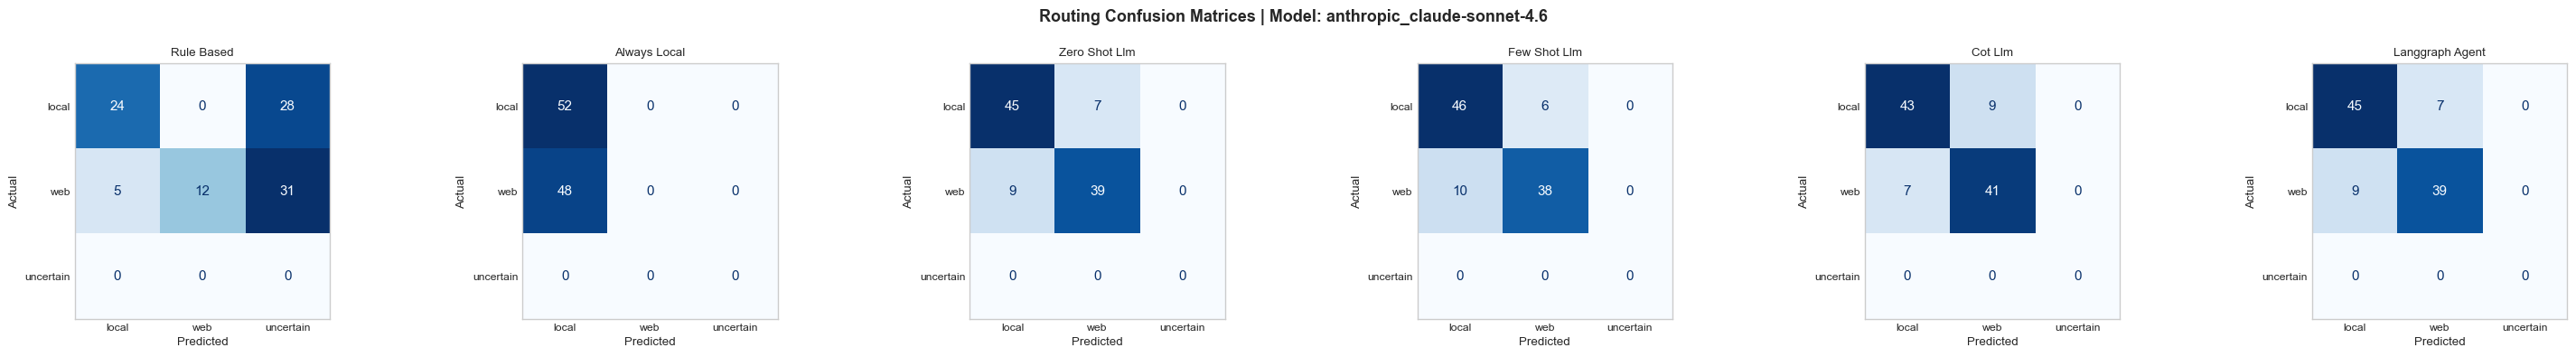

Saved: confusion_matrices_anthropic_claude-sonnet-4.6.png


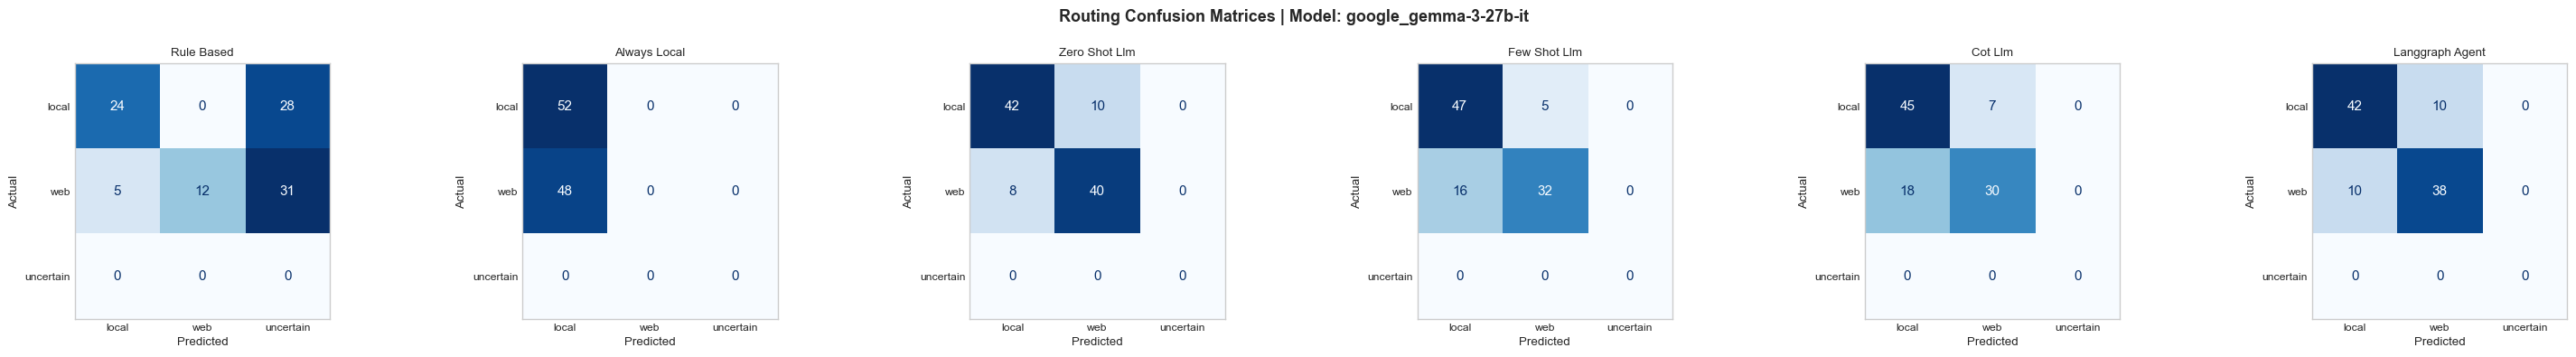

Saved: confusion_matrices_google_gemma-3-27b-it.png


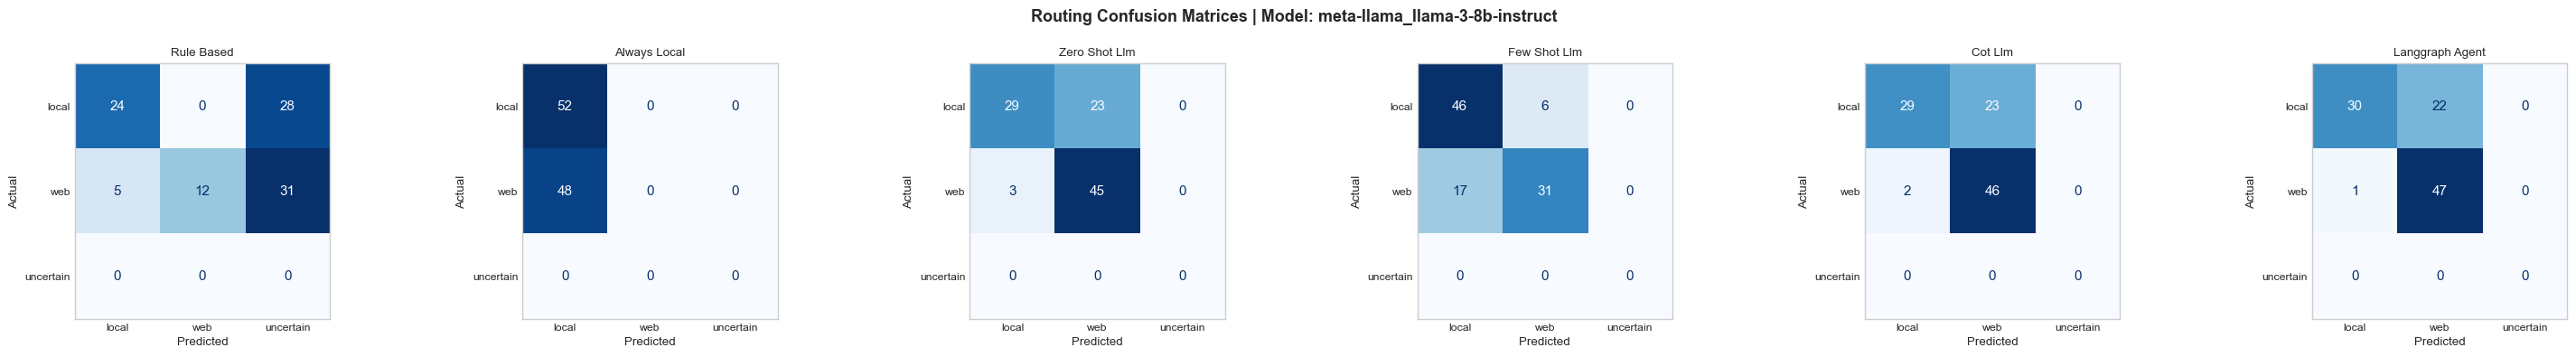

Saved: confusion_matrices_meta-llama_llama-3-8b-instruct.png


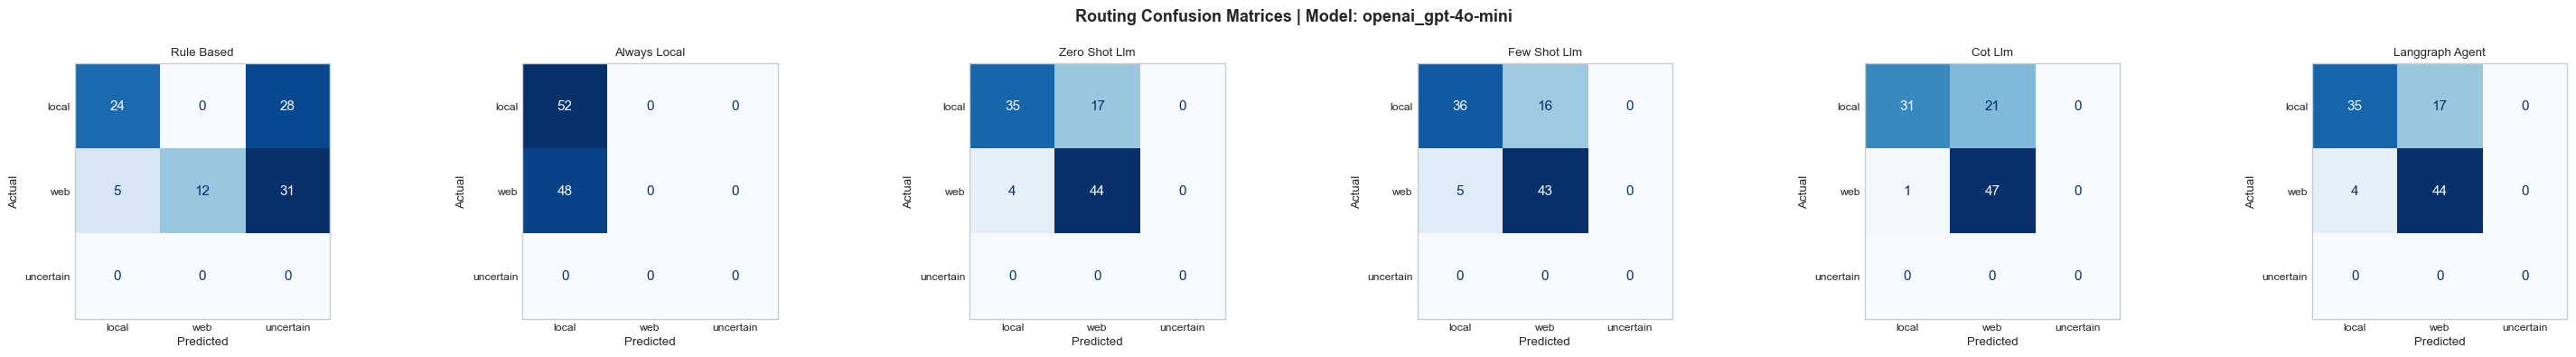

Saved: confusion_matrices_openai_gpt-4o-mini.png


In [29]:
all_csvs = sorted(RESULTS_DIR.glob("routing_results_*.csv"))
labels = ["local", "web", "uncertain"]

for csv_path in all_csvs:
    temp_df = pd.read_csv(csv_path)
    model_name = csv_path.stem.replace("routing_results_", "")
    routers = [c for c in temp_df.columns if c.endswith("_tool") and c != "ground_truth"]

    fig, axes = plt.subplots(1, len(routers), figsize=(5 * len(routers), 4))
    if len(routers) == 1:
        axes = [axes]

    for ax, router in zip(axes, routers):
        cm = confusion_matrix(temp_df["ground_truth"], temp_df[router], labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap="Blues", ax=ax, colorbar=False)
        ax.grid(False)
        ax.set_title(f"{router.replace('_tool', '').replace('_', ' ').title()}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle(f"Routing Confusion Matrices | Model: {model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    safe_name = model_name.replace("/", "_").replace("\\", "_")
    plt.savefig(f"../data/results/confusion_matrices_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: confusion_matrices_{safe_name}.png")

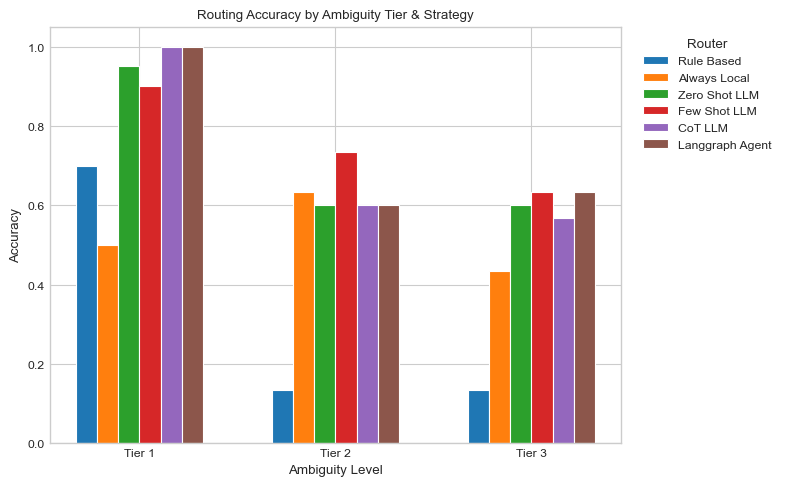

In [35]:
tier_accuracies = []
for tier in [1, 2, 3]:
    mask = df["ambiguity_tier"] == tier
    for router in routers:
        acc = (df[mask][router] == df[mask]["ground_truth"]).mean()
        tier_accuracies.append({
            "router": router.replace("_tool", "").replace("_", " ").title().replace("Llm", "LLM").replace("Cot", "CoT"),
            "tier": f"Tier {tier}",
            "accuracy": acc
        })

acc_df = pd.DataFrame(tier_accuracies)
tier_labels = ["Tier 1", "Tier 2", "Tier 3"]
router_labels = acc_df["router"].unique()
x = np.arange(len(tier_labels))
n = len(router_labels)
width = 0.65 / n
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, router in enumerate(router_labels):
    vals = [acc_df[(acc_df["router"] == router) & (acc_df["tier"] == t)]["accuracy"].values[0] for t in tier_labels]
    offset = (i - (n - 1) / 2) * width
    ax.bar(x + offset, vals, width, color=colors[i % len(colors)], label=router, edgecolor="white", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.set_title("Routing Accuracy by Ambiguity Tier & Strategy")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Ambiguity Level")
ax.legend(title="Router", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../data/results/accuracy_vs_tier.png", dpi=300, bbox_inches="tight")
plt.show()

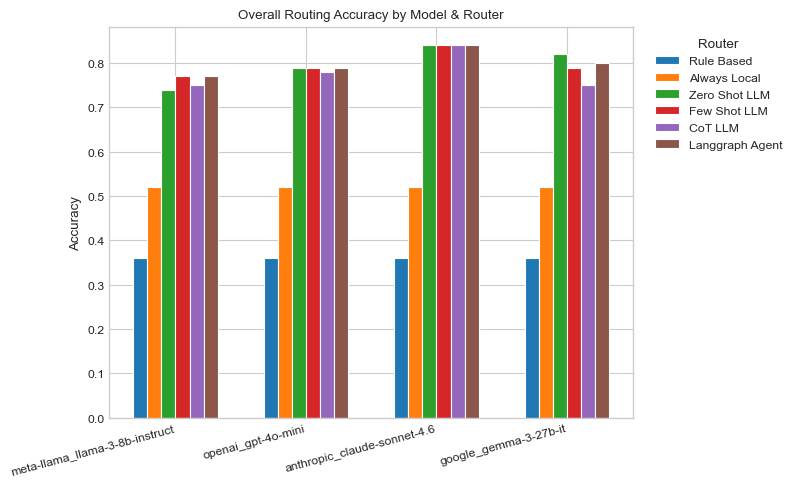

In [33]:
all_csvs = list(RESULTS_DIR.glob("routing_results_*.csv"))
if len(all_csvs) > 1:
    model_acc = []
    for csv_p in all_csvs:
        temp_df = pd.read_csv(csv_p)
        m_name = csv_p.stem.replace("routing_results_", "")
        for router in [c for c in temp_df.columns if c.endswith("_tool")]:
            acc = (temp_df[router] == temp_df["ground_truth"]).mean()
            model_acc.append({"model": m_name, "router": router.replace("_tool", "").replace("_", " ").title().replace("Llm", "LLM").replace("Cot", "CoT"), "accuracy": acc})
    comp_df = pd.DataFrame(model_acc)

    model_labels = comp_df["model"].unique()
    router_labels = comp_df["router"].unique()
    x = np.arange(len(model_labels))
    n = len(router_labels)
    width = 0.65 / n
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, router in enumerate(router_labels):
        vals = [comp_df[(comp_df["model"] == m) & (comp_df["router"] == router)]["accuracy"].values[0] for m in model_labels]
        offset = (i - (n - 1) / 2) * width
        ax.bar(x + offset, vals, width, color=colors[i % len(colors)], label=router, edgecolor="white", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, ha="right")
    ax.set_title("Overall Routing Accuracy by Model & Router")
    ax.set_ylabel("Accuracy")
    ax.legend(title="Router", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("../data/results/model_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

In [32]:
print("📝 Exporting Top Failure Cases for Report...")
failures = []
for router in routers:
    errs = df[df[router] != df["ground_truth"]]
    for _, row in errs.head(3).iterrows():
        failures.append({
            "router": router.replace("_tool", ""),
            "query_id": row["query_id"],
            "prompt": row["prompt"],
            "ground_truth": row["ground_truth"],
            "predicted": row[router],
            "ambiguity_tier": row["ambiguity_tier"]
        })
 
pd.DataFrame(failures).to_csv("../data/results/qualitative_failures.csv", index=False)
print("✅ Saved to ../data/results/qualitative_failures.csv")
print("\nSample Failures:")
for f in failures[:3]:
    print(f"[{f['router']}] Q{f['query_id']} (Tier {f['ambiguity_tier']})")
    print(f"  GT: {f['ground_truth']} | Pred: {f['predicted']}")
    print(f"  Prompt: \"{f['prompt']}\"\n")

📝 Exporting Top Failure Cases for Report...
✅ Saved to ../data/results/qualitative_failures.csv

Sample Failures:
[rule_based] Q7 (Tier 1)
  GT: web | Pred: local
  Prompt: "What has Adobe announced in the past month regarding new product launches?"

[rule_based] Q8 (Tier 1)
  GT: web | Pred: uncertain
  Prompt: "Which Wall Street analysts have upgraded or downgraded Airbnb stock in the last 30 days?"

[rule_based] Q10 (Tier 1)
  GT: web | Pred: uncertain
  Prompt: "What new credit card product did American Express launch this quarter?"

